<a href="https://colab.research.google.com/github/nadeemkhanrtm1/video-game-analysis/blob/main/video_game_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Video Game Analysis

In [164]:
import numpy as np;
import pandas as pd;
from sklearn.impute import SimpleImputer;
import matplotlib.pyplot as plt;

In [76]:
data = pd.read_csv("video-game-analysis.csv")

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [78]:
data.shape

(64016, 14)

In [79]:
data = data.drop(columns=["img"])

In [80]:
data.shape

(64016, 13)

In [81]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


In [82]:
data.convert_dtypes()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,<NA>
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.6,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,<NA>
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,<NA>,15.86,9.06,0.06,5.33,1.42,2013-09-17,<NA>
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2016-08-11,2019-01-28
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2020-07-30,2020-05-09
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2020-07-30,2020-05-09
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2019-02-28,2019-02-24


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  object 
 1   console       64016 non-null  object 
 2   genre         64016 non-null  object 
 3   publisher     64016 non-null  object 
 4   developer     63999 non-null  object 
 5   critic_score  6678 non-null   float64
 6   total_sales   18922 non-null  float64
 7   na_sales      12637 non-null  float64
 8   jp_sales      6726 non-null   float64
 9   pal_sales     12824 non-null  float64
 10  other_sales   15128 non-null  float64
 11  release_date  56965 non-null  object 
 12  last_update   17879 non-null  object 
dtypes: float64(6), object(7)
memory usage: 6.3+ MB


In [84]:
data = data.convert_dtypes()

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  string 
 1   console       64016 non-null  string 
 2   genre         64016 non-null  string 
 3   publisher     64016 non-null  string 
 4   developer     63999 non-null  string 
 5   critic_score  6678 non-null   Float64
 6   total_sales   18922 non-null  Float64
 7   na_sales      12637 non-null  Float64
 8   jp_sales      6726 non-null   Float64
 9   pal_sales     12824 non-null  Float64
 10  other_sales   15128 non-null  Float64
 11  release_date  56965 non-null  string 
 12  last_update   17879 non-null  string 
dtypes: Float64(6), string(7)
memory usage: 6.7 MB


In [86]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


In [87]:
data.select_dtypes("number")

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,9.4,20.32,6.37,0.99,9.85,3.12
1,9.7,19.39,6.06,0.6,9.71,3.02
2,9.6,16.15,8.41,0.47,5.49,1.78
3,<NA>,15.86,9.06,0.06,5.33,1.42
4,8.1,15.09,6.18,0.41,6.05,2.44
...,...,...,...,...,...,...
64011,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64013,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64014,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [88]:
data.select_dtypes(include=np.number)

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
0,9.4,20.32,6.37,0.99,9.85,3.12
1,9.7,19.39,6.06,0.6,9.71,3.02
2,9.6,16.15,8.41,0.47,5.49,1.78
3,<NA>,15.86,9.06,0.06,5.33,1.42
4,8.1,15.09,6.18,0.41,6.05,2.44
...,...,...,...,...,...,...
64011,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64012,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64013,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
64014,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [89]:
nums_cols = data.select_dtypes('number').columns.tolist()

In [90]:
imputer = SimpleImputer(strategy='mean')

In [91]:
imputer.fit(data[nums_cols])

## data[nums_cols] = imputer.fit_transform(data[nums_cols])

SimpleImputer()

In [92]:
data.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,<NA>
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.6,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,<NA>
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,<NA>,15.86,9.06,0.06,5.33,1.42,2013-09-17,<NA>
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [93]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  string 
 1   console       64016 non-null  string 
 2   genre         64016 non-null  string 
 3   publisher     64016 non-null  string 
 4   developer     63999 non-null  string 
 5   critic_score  6678 non-null   Float64
 6   total_sales   18922 non-null  Float64
 7   na_sales      12637 non-null  Float64
 8   jp_sales      6726 non-null   Float64
 9   pal_sales     12824 non-null  Float64
 10  other_sales   15128 non-null  Float64
 11  release_date  56965 non-null  string 
 12  last_update   17879 non-null  string 
dtypes: Float64(6), string(7)
memory usage: 6.7 MB


In [95]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290
pal_sales,51192


In [96]:
nums_cols

['critic_score',
 'total_sales',
 'na_sales',
 'jp_sales',
 'pal_sales',
 'other_sales']

In [97]:
imputers = SimpleImputer(strategy='mean')

In [98]:
imputers

SimpleImputer()

In [99]:
data[nums_cols] = imputers.fit_transform(data[nums_cols])

In [100]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,0
total_sales,0
na_sales,0
jp_sales,0
pal_sales,0


In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         64016 non-null  string 
 1   console       64016 non-null  string 
 2   genre         64016 non-null  string 
 3   publisher     64016 non-null  string 
 4   developer     63999 non-null  string 
 5   critic_score  64016 non-null  float64
 6   total_sales   64016 non-null  float64
 7   na_sales      64016 non-null  float64
 8   jp_sales      64016 non-null  float64
 9   pal_sales     64016 non-null  float64
 10  other_sales   64016 non-null  float64
 11  release_date  56965 non-null  string 
 12  last_update   17879 non-null  string 
dtypes: float64(6), string(7)
memory usage: 6.3 MB


In [102]:
dates_cols = ['release_date', 'last_update'];

In [103]:
dates_cols

['release_date', 'last_update']

In [104]:
data['release_date'] = pd.to_datetime(data['release_date']);
data['last_update'] = pd.to_datetime(data['last_update']);

In [105]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         64016 non-null  string        
 1   console       64016 non-null  string        
 2   genre         64016 non-null  string        
 3   publisher     64016 non-null  string        
 4   developer     63999 non-null  string        
 5   critic_score  64016 non-null  float64       
 6   total_sales   64016 non-null  float64       
 7   na_sales      64016 non-null  float64       
 8   jp_sales      64016 non-null  float64       
 9   pal_sales     64016 non-null  float64       
 10  other_sales   64016 non-null  float64       
 11  release_date  56965 non-null  datetime64[ns]
 12  last_update   17879 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(6), string(5)
memory usage: 6.3 MB


# 1. Drop any row that has at least one missing value (Default)
df_cleaned = df.dropna()

# 2. Drop columns with any missing values
df_cols_dropped = df.dropna(axis=1)

# 3. Only drop rows where ALL values are missing
df_all_na = df.dropna(how='all')

# 4. Drop rows based on a specific column
df_subset = df.dropna(subset=['A'])

In [106]:
data = data.dropna(subset=['developer'])

In [107]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,0
total_sales,0
na_sales,0
jp_sales,0
pal_sales,0


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63999 entries, 0 to 64015
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         63999 non-null  string        
 1   console       63999 non-null  string        
 2   genre         63999 non-null  string        
 3   publisher     63999 non-null  string        
 4   developer     63999 non-null  string        
 5   critic_score  63999 non-null  float64       
 6   total_sales   63999 non-null  float64       
 7   na_sales      63999 non-null  float64       
 8   jp_sales      63999 non-null  float64       
 9   pal_sales     63999 non-null  float64       
 10  other_sales   63999 non-null  float64       
 11  release_date  56954 non-null  datetime64[ns]
 12  last_update   17877 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(6), string(5)
memory usage: 6.8 MB


In [111]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,0
total_sales,0
na_sales,0
jp_sales,0
pal_sales,0


In [110]:
data['last_update'] = data['last_update'].fillna(data['release_date'])

In [117]:
(data['release_date'].isnull() & data['last_update'].isnull()).sum().astype(int)

np.int64(1746)

In [118]:
1746 - 7045

-5299

In [119]:
data.shape

(63999, 13)

In [127]:
## df['release_date'] = df['release_date'].fillna(df['release_date'].mode()[0])


# data['release_date'] = data['release_date'].fillna(data['release_date'].mode)
data['last_update'].median()

Timestamp('2009-09-30 00:00:00')

In [123]:
data['release_date']

,release_date
0,2013-09-17
1,2014-11-18
2,2002-10-28
3,2013-09-17
4,2015-11-06
...,...
64011,2016-08-11
64012,2020-07-30
64013,2020-07-30
64014,2019-02-28


In [128]:
data['release_date'] = data['release_date'].fillna(data['release_date'].mode()[0])

In [129]:
data['last_update'] = data['last_update'].fillna(data['last_update'].mode()[0])

In [130]:
data.isna().sum()

,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,0
total_sales,0
na_sales,0
jp_sales,0
pal_sales,0


In [131]:
data.shape

(63999, 13)

In [171]:
total_sales_by_title = data.groupby('title')['total_sales'].sum().sort_values(ascending=False)

In [180]:
total_sales_by_title = total_sales_by_title.reset_index().head(10)

In [181]:
total_sales_by_title

,index,title,total_sales
0,0,Grand Theft Auto V,65.686451
1,1,Call of Duty: Black Ops,32.037338
2,2,Call of Duty: Modern Warfare 3,31.059113
3,3,Call of Duty: Black Ops II,29.939113
4,4,Call of Duty: Ghosts,29.149113
5,5,Call of Duty: Black Ops 3,26.720000
6,6,Minecraft,26.104676
7,7,Call of Duty: Modern Warfare 2,26.067338
8,8,Grand Theft Auto IV,23.228225
9,9,Call of Duty: Advanced Warfare,21.780000


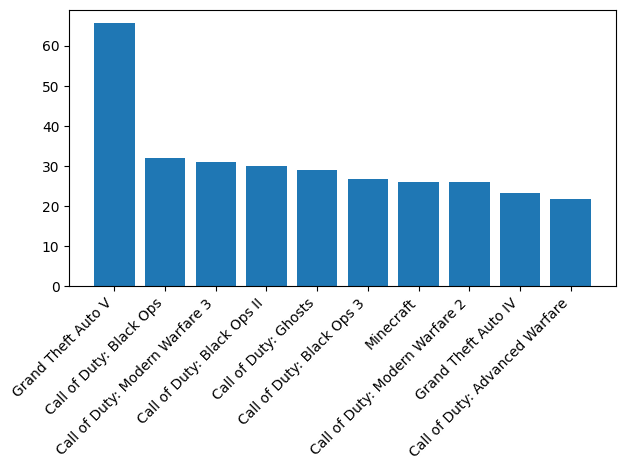

In [187]:
plt.bar(total_sales_by_title['title'], total_sales_by_title['total_sales']);
plt.xticks(rotation=45, ha='right') # Rotate 45 degrees, align right
plt.tight_layout() # Adjusts plot to prevent clipping of labels
plt.show()

In [192]:
data.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.22044,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [193]:
data['total_sales'].max()

20.32

In [195]:
top_10 = data.nlargest(10, 'total_sales')

In [196]:
top_10

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.22044,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.70000,14.82,9.07,0.13,4.29,1.33,2011-11-08,2011-11-08
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.80000,14.74,9.76,0.11,3.73,1.14,2010-11-09,2010-11-09
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.80000,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018-11-02
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.40000,13.86,8.27,0.07,4.32,1.20,2012-11-13,2018-04-07
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.00000,13.80,4.99,0.65,5.88,2.28,2012-11-13,2018-04-07


/tmp/ipykernel_13035/3702255587.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='total_sales', y='title', palette='viridis')


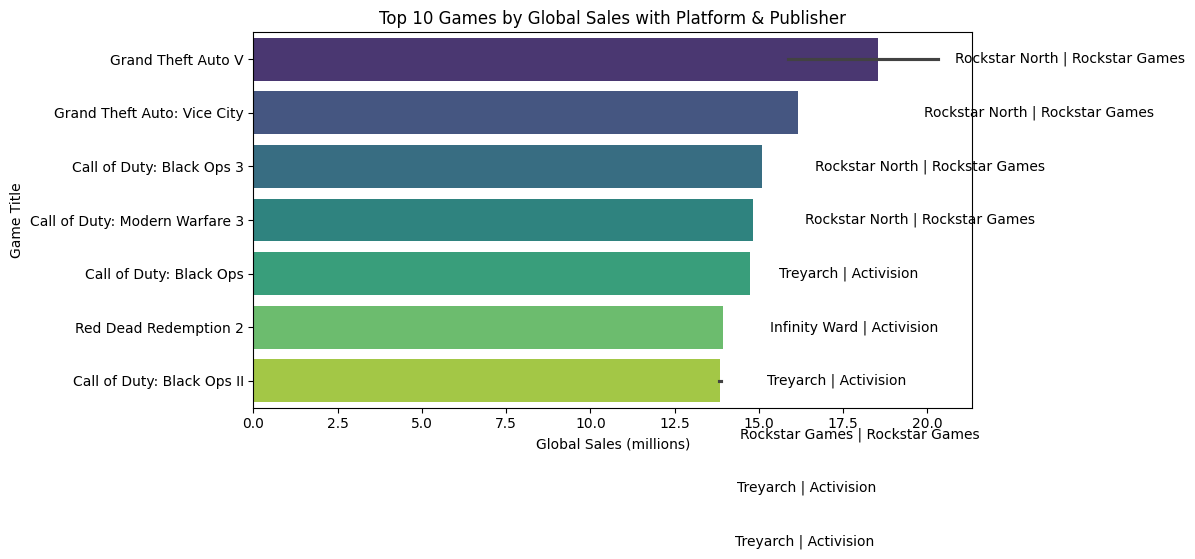

In [205]:
top10 = data.nlargest(10, 'total_sales')[['title', 'total_sales', 'developer', 'publisher']]

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='total_sales', y='title', palette='viridis')

# Add platform & publisher as annotation next to each bar
for i, (_, row) in enumerate(top10.iterrows()):
    plt.text(row['total_sales'] + 0.5, i,
             f"{row['developer']} | {row['publisher']}",
             va='center')

plt.xlabel('Global Sales (millions)')
plt.ylabel('Game Title')
plt.title('Top 10 Games by Global Sales with Platform & Publisher')
plt.tight_layout()
plt.show()
